In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
dataset, dataset_info = tfds.load('malaria', with_info=True, as_supervised=True, shuffle_files=True, split=['train'])

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.L8FKHT_1.0.0/malaria-train.tfrecord*...:   0%|         …

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


In [ ]:
dataset

[<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>]

In [ ]:
dataset_info

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasit

In [ ]:
for data in dataset[0].take(2):
  print(data)

(<tf.Tensor: shape=(103, 103, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)>, <tf.Tensor: shape=(), dtype=int64, numpy=0>)
(<tf.Tensor: shape=(115, 157, 3), dtype=uint8, numpy=
array([[[0, 0, 0],
        [0, 0, 0],
       

In [ ]:
dataset = dataset[0].shuffle(1000, reshuffle_each_iteration=False)

In [ ]:
train_ratio = 0.8
validate_ratio = 0.1
test_ratio = 0.1
dataset_size = len(dataset)
train_dataset = dataset.take(int(dataset_size * train_ratio))
remaining = dataset.skip(int(dataset_size * train_ratio))
validate_dataset = remaining.take(int(dataset_size * validate_ratio))
test_dataset = remaining.skip(int(dataset_size * validate_ratio))

In [ ]:
print(list(train_dataset.take(1).as_numpy_iterator()))

[(array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8), np.int64(1))]


In [ ]:
print(list(validate_dataset.take(1).as_numpy_iterator()))

[(array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8), np.int64(1))]


In [ ]:
print(list(test_dataset.take(1).as_numpy_iterator()))

[(array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8), np.int64(1))]


In [ ]:
print(dataset_size)
print(len(train_dataset))
print(len(validate_dataset))
print(len(test_dataset))

27558
22046
2755
2757


In [ ]:
dataset_info.features['label'].int2str(0)

'parasitized'

In [ ]:
dataset_info.features['label'].int2str(1)

'uninfected'

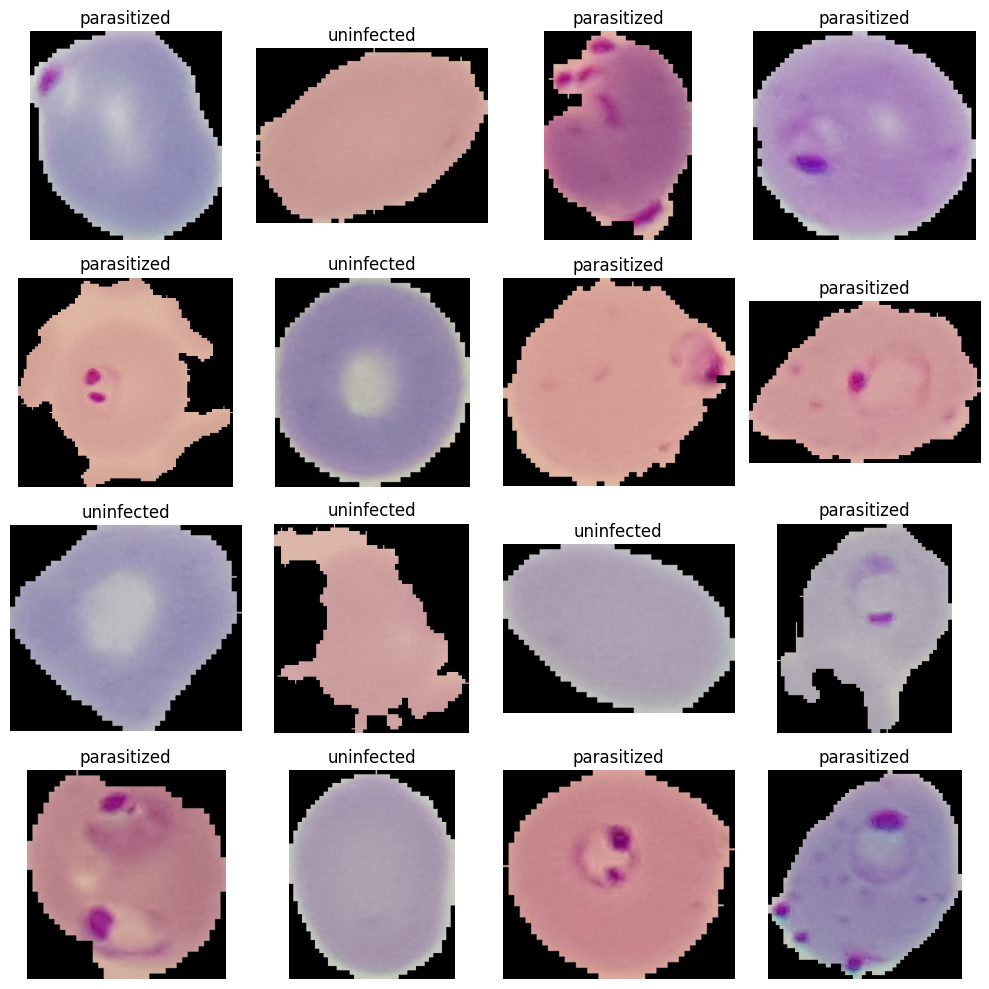

In [ ]:
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_dataset.take(16)):
  ax = plt.subplot(4, 4, i+1)
  plt.imshow(image)
  plt.title(dataset_info.features['label'].int2str(label))
  plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    image = preprocess_input(image)
    return image, label

In [ ]:
train_dataset = train_dataset.map(preprocess)
validate_dataset = validate_dataset.map(preprocess)
test_dataset = test_dataset.map(preprocess)

In [ ]:
train_dataset = train_dataset.shuffle(buffer_size=1000, reshuffle_each_iteration=True).batch(32).prefetch(tf.data.AUTOTUNE)
validate_dataset = validate_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
validate_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
test_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

In [ ]:
mobileNetmodel = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(units = 1, activation='sigmoid')
    ])
mobileNetmodel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
mobileNetmodel.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = mobileNetmodel.fit(
    train_dataset,
    validation_data=validate_dataset,
    epochs=10,
    verbose=1
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.9507 - loss: 0.1422 - val_accuracy: 0.9419 - val_loss: 0.1552
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.9512 - loss: 0.1398 - val_accuracy: 0.9452 - val_loss: 0.1520
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 60ms/step - accuracy: 0.9517 - loss: 0.1379 - val_accuracy: 0.9452 - val_loss: 0.1630
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 50s 71ms/step - accuracy: 0.9515 - loss: 0.1374 - val_accuracy: 0.9426 - val_loss: 0.1628
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.9531 - loss: 0.1321 - val_accuracy: 0.9474 - val_loss: 0.1581
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 60ms/step - accuracy: 0.9530 - loss: 0.1316 - val_accuracy: 0.9481 - val_loss: 0.1554
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 43s 60ms/step - accuracy: 0.9542 - loss: 0.1302 - val_accuracy: 0.9488 - val_loss: 0.1459
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 44s 60ms/step - accuracy: 0.9545 - loss: 0.1293 - 

In [ ]:
mobileNetmodel.evaluate(test_dataset)

87/87 ━━━━━━━━━━━━━━━━━━━━ 25s 155ms/step - accuracy: 0.9456 - loss: 0.1505


[0.150534525513649, 0.9455930590629578]

In [ ]:
def parasite(x):
  if(x<0.5):
    return 'Parasitized'
  else:
    return 'Uninfected'

In [ ]:
for image, label in test_dataset.take(1):
    prob = mobileNetmodel.predict(image)[0][0]
    print(parasite(prob))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Uninfected


In [ ]:
def get_label_name(label):
    return 'Parasitized' if label == 0 else 'Uninfected'

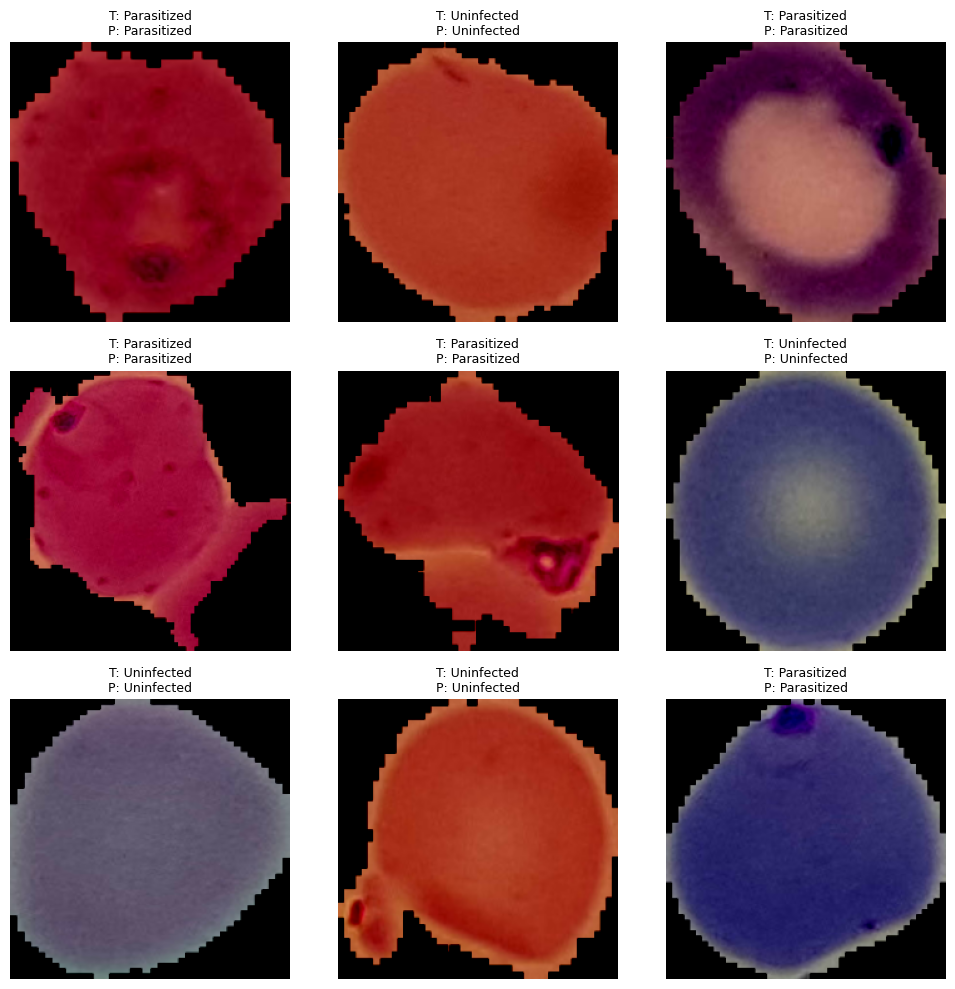

In [ ]:
plt.figure(figsize=(10, 10))

for i, (image, label) in enumerate(test_dataset.take(9)):
    ax = plt.subplot(3, 3, i + 1)

    img = image[0]

    true_label = get_label_name(label.numpy()[0])
    prob = mobileNetmodel.predict(image, verbose=0)[0][0]
    pred_label = parasite(prob)

    plt.imshow(img)
    ax.set_title(f"T: {true_label}\nP: {pred_label}", fontsize=9)

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
mobileNetmodel.save("malariaPretrain_model.keras")

In [ ]:
from google.colab import files
files.download("malariaPretrain_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
mobileNetmodel.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = mobileNetmodel.fit(
    train_dataset,
    validation_data=validate_dataset,
    epochs=10,
    verbose = 1
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.9696 - loss: 0.0857 - val_accuracy: 0.9546 - val_loss: 0.1625
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.9770 - loss: 0.0648 - val_accuracy: 0.9590 - val_loss: 0.1407
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 55s 77ms/step - accuracy: 0.9824 - loss: 0.0511 - val_accuracy: 0.9564 - val_loss: 0.1521
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 74s 66ms/step - accuracy: 0.9875 - loss: 0.0405 - val_accuracy: 0.9644 - val_loss: 0.1304
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.9901 - loss: 0.0324 - val_accuracy: 0.9601 - val_loss: 0.1345
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.9930 - loss: 0.0246 - val_accuracy: 0.9615 - val_loss: 0.1524
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.9948 - loss: 0.0213 - val_accuracy: 0.9619 - val_loss: 0.1401
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 47s 65ms/step - accuracy: 0.9958 - loss: 0.0166 - 

In [ ]:
mobileNetmodel.evaluate(test_dataset)

87/87 ━━━━━━━━━━━━━━━━━━━━ 17s 70ms/step - accuracy: 0.9572 - loss: 0.1593


[0.15929533541202545, 0.9571998715400696]

In [ ]:
mobileNetmodel.save("malaria_finetuned_model.keras")

In [ ]:
from google.colab import files
files.download("malaria_finetuned_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

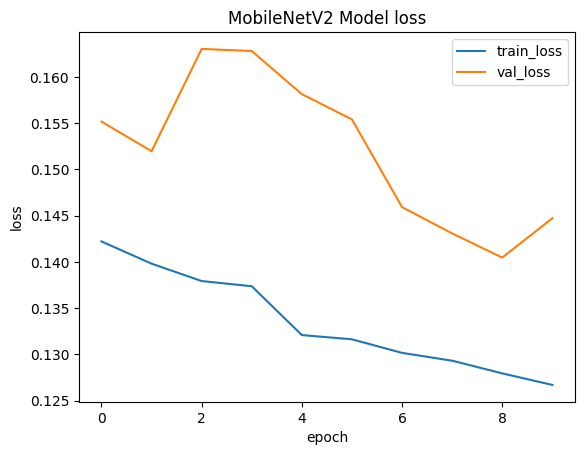

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('MobileNetV2 Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])

plt.savefig("mobilenet_loss.png")
plt.show()

In [ ]:
from google.colab import files
files.download("mobilenet_loss.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

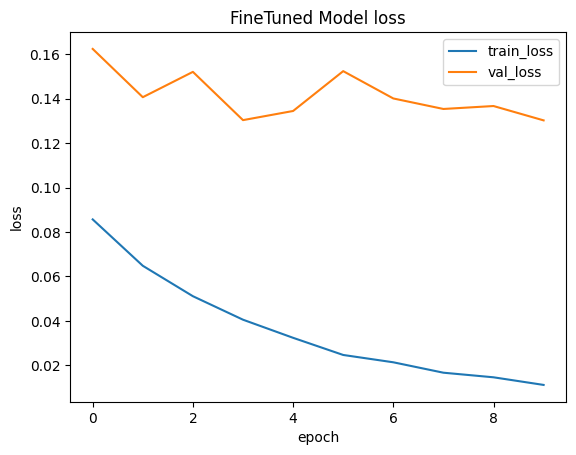

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure()
plt.plot(history_finetune.history['loss'])
plt.plot(history_finetune.history['val_loss'])
plt.title('FineTuned Model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])

plt.savefig("mobilenetFinetune_loss.png")
plt.show()
from google.colab import files
files.download("mobilenetFinetune_loss.png")

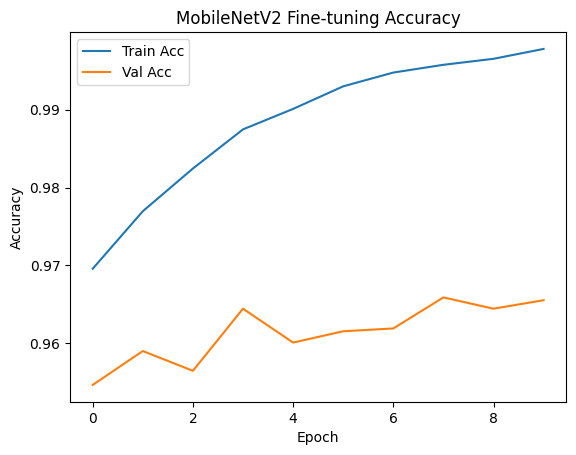

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure()

plt.plot(history_finetune.history['accuracy'], label='Train Acc')
plt.plot(history_finetune.history['val_accuracy'], label='Val Acc')

plt.title('MobileNetV2 Fine-tuning Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.savefig("mobilenetFinetune_acc.png")
plt.show()

from google.colab import files
files.download("mobilenetFinetune_acc.png")

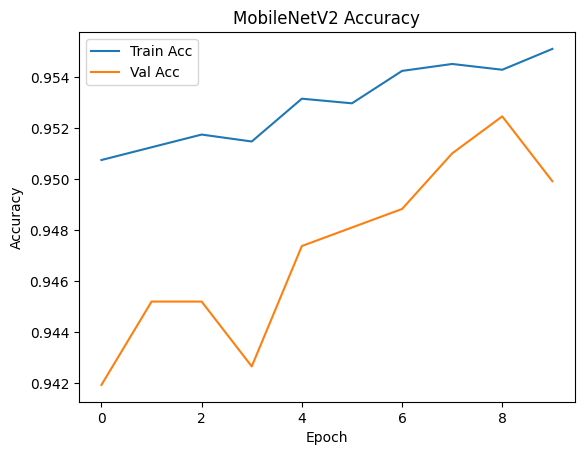

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure()

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')

plt.title('MobileNetV2 Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.savefig("mobilenet_acc.png")
plt.show()

from google.colab import files
files.download("mobilenet_acc.png")